# HEROS Phase 1 — Dataset Inventory, Cleaning & Preparation

**Project:** Chinatown HEROS (Health & Environmental Research in Open Spaces)  
**Study period:** July 19 – August 23, 2023  
**Temporal resolution:** 10-minute intervals  
**Sites:** 12 open-space locations in Boston's Chinatown  

This notebook demonstrates the complete Phase 1 data-cleaning pipeline — from raw data loading through imputation, outlier treatment, normalization, and final export.

## Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
%matplotlib inline

# Paths (relative to reports/phase1/)
RAW = Path('../../data/raw')
OUT = Path('../../figures')
OUT.mkdir(exist_ok=True)

report = {}  # collects all Phase 1 findings

## 1.1 — Dataset Catalog

We begin by cataloging every dataset used in this project.

In [ ]:
catalog = [
    {"filename": "data_HEROS.xlsx", "source": "Project team (Purple Air, Kestrel, Weather Stn, MassDEP FEM)", "status": "present"},
    {"filename": "Codebook_HEROS.xlsx", "source": "Project team — data dictionary", "status": "present"},
    {"filename": "landuse_HEROS.xlsx", "source": "Project team — MassGIS land-use buffers (25m, 50m)", "status": "present"},
    {"filename": "EPA AQS hourly pollutants (CO, SO2, NO2, Ozone)", "source": "https://aqs.epa.gov/aqsweb/airdata/download_files.html", "status": "fetched"},
    {"filename": "EPA AQS PM2.5 FEM (param 88101)", "source": "EPA AQS (site 25-025-0045)", "status": "fetched"},
]

cat_df = pd.DataFrame(catalog)
display(cat_df.style.hide(axis='index'))
report["catalog"] = catalog

filename,source,status
data_HEROS.xlsx,"Project team (Purple Air, Kestrel, Weather Stn, MassDEP FEM)",present
Codebook_HEROS.xlsx,Project team — data dictionary,present
landuse_HEROS.xlsx,"Project team — MassGIS land-use buffers (25m, 50m)",present
"EPA AQS hourly pollutants (CO, SO2, NO2, Ozone)",https://aqs.epa.gov/aqsweb/airdata/download_files.html,fetched
EPA AQS PM2.5 FEM (param 88101),EPA AQS (site 25-025-0045),fetched


## 1.2 — Load & Inspect Raw Data

### Main sensor dataset (`data_HEROS.xlsx`)

In [ ]:
# --- Main sensor data ---
df = pd.read_excel(RAW / "data_HEROS.xlsx", sheet_name="Sheet 1")
df["date"] = pd.to_datetime(df["date"])

print(f"data_HEROS.xlsx: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
print(f"Sites ({df['siteID'].nunique()}): {sorted(df['siteID'].unique())}")
print(f"\nColumn dtypes:")
for c in df.columns:
    print(f"  {c}: {df[c].dtype}")

report["main_data"] = {
    "rows": int(df.shape[0]),
    "cols": int(df.shape[1]),
    "date_min": str(df["date"].min()),
    "date_max": str(df["date"].max()),
    "sites": sorted(df["siteID"].unique().tolist()),
    "n_sites": int(df["siteID"].nunique()),
}

data_HEROS.xlsx: 48,123 rows × 20 columns
Date range: 2023-07-19 16:40:00 → 2023-08-23 15:50:00
Sites (12): ['berkley', 'castle', 'chin', 'dewey', 'eliotnorton', 'greenway', 'lyndenboro', 'msh', 'oxford', 'reggie', 'taitung', 'tufts']

Column dtypes:
  siteID: object
  date: datetime64[ns]
  kes_mean_temp_f: float64
  kes_mean_wbgt_f: float64
  kes_mean_humid_pct: float64
  kes_mean_press_inHg: float64
  kes_mean_heat_f: float64
  kes_mean_dew_f: float64
  pa_mean_pm2_5_atm_b_corr_2: float64
  mean_temp_out_f: float64
  mean_out_hum_pct: float64
  mean_dew_pt_f: float64
  mean_wind_speed_mph: float64
  wind_direction_degrees_kr: float64
  mean_heat_index_f: float64
  mean_thw_index_f: float64
  dep_FEM_chinatown_pm2_5_ug_m3: float64
  dep_FEM_nubian_pm2_5_ug_m3: float64
  dep_FEM_nubian_temp_f: float64
  dep_FEM_nubian_humid_pct: float64


### Codebook validation

In [ ]:
# --- Codebook ---
cb = pd.read_excel(RAW / "Codebook_HEROS.xlsx")
codebook_vars = cb["Variable Name"].tolist()
data_cols = df.columns.tolist()
missing_in_data = [v for v in codebook_vars if v not in data_cols]
extra_in_data = [c for c in data_cols if c not in codebook_vars]

print(f"Codebook has {len(codebook_vars)} variables.")
if missing_in_data:
    print(f"  ⚠ In codebook but NOT in data: {missing_in_data}")
if extra_in_data:
    print(f"  ⚠ In data but NOT in codebook: {extra_in_data}")

report["codebook_check"] = {
    "codebook_vars": len(codebook_vars),
    "missing_in_data": missing_in_data,
    "extra_in_data": extra_in_data,
}

Codebook has 21 variables.
  ⚠ In codebook but NOT in data: ['dep_FEM_nubian_pm10_stp_ug_m3']


### Land-use data

In [ ]:
# --- Land-use ---
lu = pd.read_excel(RAW / "landuse_HEROS.xlsx", sheet_name="data")
print(f"landuse_HEROS.xlsx: {lu.shape[0]} rows × {lu.shape[1]} columns")
print(f"Sites: {lu['Site'].unique().tolist()}")
print(f"Distances: {sorted(lu['Distance'].unique())}")
display(lu.describe().round(4))

report["landuse"] = {
    "rows": int(lu.shape[0]),
    "sites": lu["Site"].unique().tolist(),
    "distances": sorted(lu["Distance"].unique().tolist()),
}

landuse_HEROS.xlsx: 24 rows × 8 columns
Sites: ['Berkeley Garden', 'Castle Square', 'Chin Park', 'Dewey Square', 'Eliot Norton Park', 'Lyndboro Park', 'Mary Soo Hoo Park', 'One Greenway', 'Oxford Place', 'Reggie Wong', 'Tai Tung', 'Tufts Community Garden']
Distances: [np.int64(25), np.int64(50)]


,Distance,Buffer_Area_msq,Roads_Area_Percent,Greenspace_Area_Percent,Trees_Area_Percent,Impervious_Area_Percent,Industrial_Area_Percent
count,24.0000,24.0000,24.0000,24.0000,24.0000,24.0000,24.0000
mean,37.5000,4908.7385,0.1596,0.1051,0.2269,0.8117,0.0175
std,12.7688,3008.5889,0.1317,0.0937,0.1869,0.1934,0.0380
min,25.0000,1963.4954,0.0000,0.0000,0.0041,0.2966,0.0000
25%,25.0000,1963.4954,0.0199,0.0173,0.0891,0.6760,0.0000
50%,37.5000,4908.7385,0.1646,0.0985,0.1687,0.8998,0.0000
75%,50.0000,7853.9816,0.2661,0.1767,0.2842,0.9502,0.0015
max,50.0000,7853.9816,0.4666,0.2742,0.7073,0.9997,0.1238


### Site name mapping

In [ ]:
# Reconcile site names across all datasets
SITE_ID_TO_NAME = {
    "berkley": "Berkeley Garden", "castle": "Castle Square",
    "chin": "Chin Park", "dewey": "Dewey Square",
    "eliotnorton": "Eliot Norton Park", "greenway": "One Greenway",
    "lyndenboro": "Lyndboro Park", "msh": "Mary Soo Hoo Park",
    "oxford": "Oxford Place", "reggie": "Reggie Wong",
    "taitung": "Tai Tung", "tufts": "Tufts Community Garden",
}
LANDUSE_NAME_TO_ID = {v: k for k, v in SITE_ID_TO_NAME.items()}

print("Site mapping (siteID → land-use name):")
for sid, name in SITE_ID_TO_NAME.items():
    in_lu = name in lu["Site"].values
    print(f"  {sid:15s} → {name:25s} {'✓ in landuse' if in_lu else '✗ NOT in landuse'}")

Site mapping (siteID → land-use name):
  berkley         → Berkeley Garden           ✓ in landuse
  castle          → Castle Square             ✓ in landuse
  chin            → Chin Park                 ✓ in landuse
  dewey           → Dewey Square              ✓ in landuse
  eliotnorton     → Eliot Norton Park         ✓ in landuse
  greenway        → One Greenway              ✓ in landuse
  lyndenboro      → Lyndboro Park             ✓ in landuse
  msh             → Mary Soo Hoo Park         ✓ in landuse
  oxford          → Oxford Place              ✓ in landuse
  reggie          → Reggie Wong               ✓ in landuse
  taitung         → Tai Tung                  ✓ in landuse
  tufts           → Tufts Community Garden    ✓ in landuse


## 1.3 — EPA AQS Data Integration

EPA AQS hourly pollutant data (Ozone, SO₂, CO, NO₂, PM2.5 FEM) was fetched from bulk download files at [aqs.epa.gov](https://aqs.epa.gov/aqsweb/airdata/download_files.html), filtered to Suffolk County stations (25-025-0042 / 0045) for the study window.

> **Note:** The EPA download step is performed by the separate script `scripts/phase1_epa_fetch.py` because the raw files are 50–300 MB each. Here we load the pre-fetched result.

In [ ]:
# Load pre-fetched EPA data
EPA_PATH = Path('../../data/epa/epa_hourly_boston.parquet')
if EPA_PATH.exists():
    epa_merged = pd.read_parquet(EPA_PATH)
    print(f"EPA hourly data: {epa_merged.shape[0]} rows × {epa_merged.shape[1]} columns")
    display(epa_merged.describe().round(4))
else:
    epa_merged = None
    print("⚠ EPA data not found — run scripts/phase1_epa_fetch.py first")

EPA hourly data: 865 rows × 5 columns


,epa_ozone,epa_so2,epa_co,epa_no2,epa_pm25_fem
count,844.0000,810.0000,846.0000,730.0000,853.0000
mean,0.0320,0.2774,0.2642,5.6014,8.3443
std,0.0114,0.0789,0.0758,4.3393,4.7718
min,0.0010,0.1000,0.1430,0.0000,1.2000
25%,0.0240,0.2000,0.2122,3.0000,4.4000
50%,0.0300,0.3000,0.2570,5.0000,7.4000
75%,0.0400,0.3000,0.3040,7.0000,11.5000
max,0.0620,1.0000,0.9880,49.0000,30.7000


## 1.4 — Missing Value Audit

We audit missingness at overall, per-variable, and per-site levels before any imputation.

In [ ]:
# Overall missingness
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
miss_overall = df[numeric_cols].isna().sum()
miss_pct_overall = (df[numeric_cols].isna().mean() * 100).round(2)

miss_summary = pd.DataFrame({"null_count": miss_overall, "null_pct": miss_pct_overall})
miss_summary = miss_summary[miss_summary["null_count"] > 0].sort_values("null_pct", ascending=False)
display(miss_summary)

,null_count,null_pct
kes_mean_temp_f,1725,3.58
kes_mean_wbgt_f,1725,3.58
kes_mean_humid_pct,1725,3.58
kes_mean_press_inHg,1725,3.58
kes_mean_heat_f,1725,3.58
kes_mean_dew_f,1725,3.58
pa_mean_pm2_5_atm_b_corr_2,1007,2.09
dep_FEM_nubian_pm2_5_ug_m3,327,0.68
dep_FEM_nubian_temp_f,285,0.59
dep_FEM_nubian_humid_pct,285,0.59


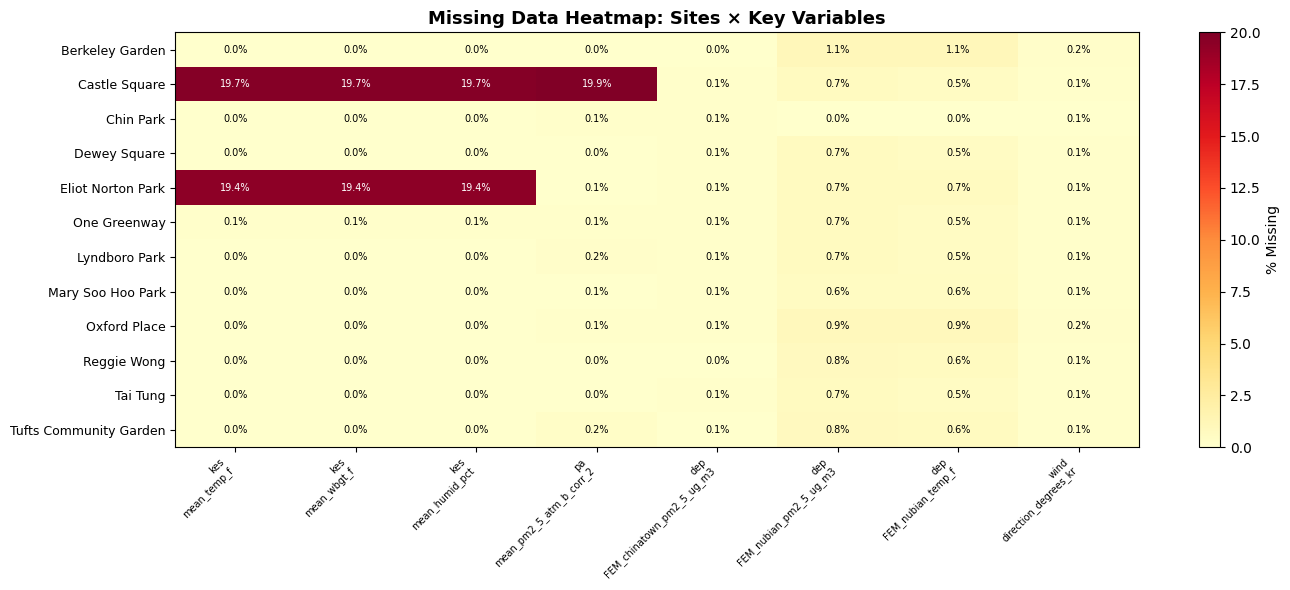

In [ ]:
# Per-site missingness for key variables
key_vars = [
    "kes_mean_temp_f", "kes_mean_wbgt_f", "kes_mean_humid_pct",
    "pa_mean_pm2_5_atm_b_corr_2",
    "dep_FEM_chinatown_pm2_5_ug_m3", "dep_FEM_nubian_pm2_5_ug_m3",
    "dep_FEM_nubian_temp_f", "wind_direction_degrees_kr",
]

sites = sorted(df["siteID"].unique())
miss_by_site = pd.DataFrame(index=sites, columns=key_vars, dtype=float)
for site in sites:
    sd = df[df["siteID"] == site]
    for var in key_vars:
        miss_by_site.loc[site, var] = round(sd[var].isna().mean() * 100, 2)

# Missing data heatmap
fig, ax = plt.subplots(figsize=(14, 6))
miss_matrix = miss_by_site.astype(float).values
im = ax.imshow(miss_matrix, cmap="YlOrRd", aspect="auto", vmin=0, vmax=20)
ax.set_xticks(range(len(key_vars)))
ax.set_xticklabels([c.replace("_", "\n", 1) for c in key_vars], fontsize=7, rotation=45, ha="right")
ax.set_yticks(range(len(sites)))
ax.set_yticklabels([SITE_ID_TO_NAME.get(s, s) for s in sites], fontsize=9)
for i in range(len(sites)):
    for j in range(len(key_vars)):
        val = miss_matrix[i, j]
        color = "white" if val > 10 else "black"
        ax.text(j, i, f"{val:.1f}%", ha="center", va="center", fontsize=7, color=color)
plt.colorbar(im, ax=ax, label="% Missing")
ax.set_title("Missing Data Heatmap: Sites × Key Variables", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

### Missing pattern classification

In [ ]:
# Kestrel columns: same rows missing across all 6 sensors
kes_cols = [c for c in df.columns if c.startswith("kes_")]
kes_null_mask = df[kes_cols].isna().all(axis=1)
kes_null_sites = df.loc[kes_null_mask, "siteID"].value_counts()
print(f"Kestrel columns (all 6): {int(kes_null_mask.sum())} rows missing ({kes_null_mask.mean()*100:.1f}%)")
print(f"  By site: {kes_null_sites.to_dict()}")
print("  Pattern: MAR — specific sites/periods with sensor offline")

# Purple Air
pa_null_mask = df["pa_mean_pm2_5_atm_b_corr_2"].isna()
pa_null_sites = df.loc[pa_null_mask, "siteID"].value_counts()
print(f"\nPurple Air PM2.5: {int(pa_null_mask.sum())} rows missing ({pa_null_mask.mean()*100:.1f}%)")
print(f"  By site: {pa_null_sites.to_dict()}")
print("  Pattern: MAR — sensor gaps or post-correction NaN (negative values set to missing)")

# DEP and weather station reference columns
for col in ["dep_FEM_chinatown_pm2_5_ug_m3", "dep_FEM_nubian_pm2_5_ug_m3",
            "dep_FEM_nubian_temp_f", "dep_FEM_nubian_humid_pct",
            "wind_direction_degrees_kr"]:
    n_null = int(df[col].isna().sum())
    pct = round(df[col].isna().mean() * 100, 2)
    pattern = "MCAR" if pct < 1 else "MAR"
    print(f"\n{col}: {n_null} missing ({pct}%) — {pattern}")

Kestrel columns (all 6): 1725 rows missing (3.6%)
  By site: {'castle': 963, 'eliotnorton': 756, 'greenway': 6}
  Pattern: MAR — specific sites/periods with sensor offline

Purple Air PM2.5: 1007 rows missing (2.1%)
  By site: {'castle': 972, 'tufts': 10, 'lyndenboro': 8, 'greenway': 4, 'oxford': 4, 'chin': 3, 'dewey': 2, 'eliotnorton': 2, 'msh': 2}
  Pattern: MAR — sensor gaps or post-correction NaN (negative values set to missing)

dep_FEM_chinatown_pm2_5_ug_m3: 39 missing (0.08%) — MCAR

dep_FEM_nubian_pm2_5_ug_m3: 327 missing (0.68%) — MCAR

dep_FEM_nubian_temp_f: 285 missing (0.59%) — MCAR

dep_FEM_nubian_humid_pct: 285 missing (0.59%) — MCAR

wind_direction_degrees_kr: 62 missing (0.13%) — MCAR


In [ ]:
# Consecutive gap analysis (for imputation strategy decisions)
print("--- Consecutive Gap Analysis (Purple Air PM2.5) ---")
for site in sites:
    sd = df[df["siteID"] == site].sort_values("date")
    is_null = sd["pa_mean_pm2_5_atm_b_corr_2"].isna()
    if is_null.sum() == 0:
        continue
    groups = (is_null != is_null.shift()).cumsum()
    gap_lengths = is_null.groupby(groups).sum()
    gap_lengths = gap_lengths[gap_lengths > 0]
    if len(gap_lengths) > 0:
        print(f"  {site}: {len(gap_lengths)} gaps, max={int(gap_lengths.max())} readings "
              f"({int(gap_lengths.max())*10} min), median={gap_lengths.median():.0f}")

print("\n--- Consecutive Gap Analysis (Kestrel Temperature) ---")
for site in sites:
    sd = df[df["siteID"] == site].sort_values("date")
    is_null = sd["kes_mean_temp_f"].isna()
    if is_null.sum() == 0:
        continue
    groups = (is_null != is_null.shift()).cumsum()
    gap_lengths = is_null.groupby(groups).sum()
    gap_lengths = gap_lengths[gap_lengths > 0]
    if len(gap_lengths) > 0:
        print(f"  {site}: {len(gap_lengths)} gaps, max={int(gap_lengths.max())} readings "
              f"({int(gap_lengths.max())*10} min), median={gap_lengths.median():.0f}")

--- Consecutive Gap Analysis (Purple Air PM2.5) ---
  castle: 7 gaps, max=963 readings (9630 min), median=2
  chin: 3 gaps, max=1 readings (10 min), median=1
  dewey: 2 gaps, max=1 readings (10 min), median=1
  eliotnorton: 2 gaps, max=1 readings (10 min), median=1
  greenway: 2 gaps, max=2 readings (20 min), median=2
  lyndenboro: 2 gaps, max=6 readings (60 min), median=4
  msh: 2 gaps, max=1 readings (10 min), median=1
  oxford: 3 gaps, max=2 readings (20 min), median=1
  tufts: 4 gaps, max=4 readings (40 min), median=2

--- Consecutive Gap Analysis (Kestrel Temperature) ---
  castle: 1 gaps, max=963 readings (9630 min), median=963
  eliotnorton: 1 gaps, max=756 readings (7560 min), median=756
  greenway: 1 gaps, max=6 readings (60 min), median=6


## 1.5 — Imputation Strategy

| Scenario | Method |
|----------|--------|
| Short gaps (≤ 30 min / 3 readings) | Linear interpolation within site |
| Moderate gaps (30 min – 2 hours / 4–12 readings) | Cubic spline interpolation within site |
| Long gaps (> 2 hours / >12 readings) | Left as NaN |
| Reference columns (DEP, Weather Station) | Forward-fill / back-fill |

Boolean `imputed_*` flags are added to track which values were imputed.

In [ ]:
# Pre-imputation descriptive stats
sensor_cols = [c for c in df.columns if c.startswith(("kes_", "pa_"))]
pre_imp_stats = df[sensor_cols].describe().round(4)
print("--- Pre-Imputation Descriptive Stats (sensor columns) ---")
display(pre_imp_stats)

# Add imputed_flag columns
for col in sensor_cols:
    df[f"imputed_{col}"] = False

--- Pre-Imputation Descriptive Stats (sensor columns) ---


,kes_mean_temp_f,kes_mean_wbgt_f,kes_mean_humid_pct,kes_mean_press_inHg,kes_mean_heat_f,kes_mean_dew_f,pa_mean_pm2_5_atm_b_corr_2
count,46398.0000,46398.0000,46398.0000,46398.0000,46398.0000,46398.0000,47116.0000
mean,74.4758,65.8608,65.9455,29.8847,75.0715,61.1071,9.4710
std,6.3645,4.8411,18.9216,0.1569,7.3233,7.1227,5.3928
min,58.4000,52.7000,18.3000,28.9200,57.7000,34.4000,-1.8126
25%,69.7000,62.6000,52.2000,29.8100,70.3000,55.6333,5.1077
50%,73.8000,66.2000,65.1000,29.9000,74.1000,62.0000,8.3058
75%,78.7000,68.9000,80.1000,29.9900,79.1188,66.2788,13.4080
max,101.9000,88.0000,100.0000,30.5400,120.7000,87.8000,46.1622


In [ ]:
# Impute per site, per variable
imputation_log = {}
for site in sites:
    site_mask = df["siteID"] == site
    sd = df.loc[site_mask].sort_values("date")
    sort_idx = sd.index

    for col in sensor_cols:
        series = df.loc[sort_idx, col].copy()
        n_orig_null = int(series.isna().sum())
        if n_orig_null == 0:
            continue

        # Identify gap lengths
        is_null = series.isna()
        groups = (is_null != is_null.shift()).cumsum()
        gap_lens = is_null.groupby(groups).transform("sum")

        short_gap_mask = is_null & (gap_lens <= 3)       # ≤30 min
        moderate_gap_mask = is_null & (gap_lens >= 4) & (gap_lens <= 12)  # 40 min – 2 hr
        # long gaps (>12) left as NaN

        # Linear interpolation (for short gaps)
        interpolated = series.interpolate(method="linear", limit_direction="both")
        filled = series.copy()
        filled.loc[short_gap_mask] = interpolated.loc[short_gap_mask]

        # Spline interpolation (for moderate gaps)
        if moderate_gap_mask.sum() > 0:
            try:
                spline_interp = series.interpolate(method="spline", order=3, limit_direction="both")
                filled.loc[moderate_gap_mask] = spline_interp.loc[moderate_gap_mask]
            except Exception:
                filled.loc[moderate_gap_mask] = interpolated.loc[moderate_gap_mask]

        n_imputed = n_orig_null - int(filled.isna().sum())

        # Update main dataframe
        df.loc[sort_idx, col] = filled.values
        df.loc[sort_idx[short_gap_mask | moderate_gap_mask], f"imputed_{col}"] = True

        if n_imputed > 0:
            imputation_log.setdefault(col, []).append(
                f"{site}: {n_imputed} imputed ({int(filled.isna().sum())} still NaN)"
            )

# Reference columns: forward-fill then back-fill
ref_cols = [
    "dep_FEM_chinatown_pm2_5_ug_m3", "dep_FEM_nubian_pm2_5_ug_m3",
    "dep_FEM_nubian_temp_f", "dep_FEM_nubian_humid_pct",
    "wind_direction_degrees_kr", "mean_temp_out_f",
    "mean_out_hum_pct", "mean_dew_pt_f", "mean_wind_speed_mph",
    "mean_heat_index_f", "mean_thw_index_f",
]
for col in ref_cols:
    if col not in df.columns:
        continue
    n_before = int(df[col].isna().sum())
    if n_before == 0:
        continue
    df[col] = df[col].ffill().bfill()
    n_after = int(df[col].isna().sum())
    print(f"  {col}: ffill/bfill filled {n_before - n_after} values ({n_after} still NaN)")

print("\n--- Imputation Log ---")
for col, entries in imputation_log.items():
    print(f"  {col}:")
    for e in entries:
        print(f"    {e}")

report["imputation"] = {
    "strategy": "linear_interp(≤30min) + spline(30min-2h) + NaN(>2h) + ffill/bfill(reference)",
    "log_summary": {k: len(v) for k, v in imputation_log.items()},
}

  dep_FEM_chinatown_pm2_5_ug_m3: ffill/bfill filled 39 values (0 still NaN)
  dep_FEM_nubian_pm2_5_ug_m3: ffill/bfill filled 327 values (0 still NaN)
  dep_FEM_nubian_temp_f: ffill/bfill filled 285 values (0 still NaN)
  dep_FEM_nubian_humid_pct: ffill/bfill filled 285 values (0 still NaN)
  wind_direction_degrees_kr: ffill/bfill filled 62 values (0 still NaN)

--- Imputation Log ---
  pa_mean_pm2_5_atm_b_corr_2:
    castle: 9 imputed (963 still NaN)
    chin: 3 imputed (0 still NaN)
    dewey: 2 imputed (0 still NaN)
    eliotnorton: 2 imputed (0 still NaN)
    greenway: 4 imputed (0 still NaN)
    lyndenboro: 8 imputed (0 still NaN)
    msh: 2 imputed (0 still NaN)
    oxford: 4 imputed (0 still NaN)
    tufts: 10 imputed (0 still NaN)
  kes_mean_temp_f:
    greenway: 6 imputed (0 still NaN)
  kes_mean_wbgt_f:
    greenway: 6 imputed (0 still NaN)
  kes_mean_humid_pct:
    greenway: 6 imputed (0 still NaN)
  kes_mean_press_inHg:
    greenway: 6 imputed (0 still NaN)
  kes_mean_heat_f

In [ ]:
# Post-imputation stats comparison
post_imp_stats = df[sensor_cols].describe().round(4)
print("--- Post-Imputation Descriptive Stats ---")
display(post_imp_stats)

print("\n--- Pre vs Post Imputation: Mean Difference ---")
for col in sensor_cols:
    pre_m = pre_imp_stats.loc["mean", col] if col in pre_imp_stats.columns else np.nan
    post_m = post_imp_stats.loc["mean", col] if col in post_imp_stats.columns else np.nan
    if pd.notna(pre_m) and pd.notna(post_m):
        diff = post_m - pre_m
        print(f"  {col}: pre={pre_m:.4f}, post={post_m:.4f}, Δ={diff:+.4f}")

--- Post-Imputation Descriptive Stats ---


,kes_mean_temp_f,kes_mean_wbgt_f,kes_mean_humid_pct,kes_mean_press_inHg,kes_mean_heat_f,kes_mean_dew_f,pa_mean_pm2_5_atm_b_corr_2
count,46404.0000,46404.0000,46404.0000,46404.0000,46404.0000,46404.0000,47160.0000
mean,74.4763,65.8600,65.9415,29.8847,75.0716,61.1054,9.4630
std,6.3643,4.8413,18.9237,0.1569,7.3229,7.1239,5.3967
min,58.4000,52.7000,18.3000,28.9200,57.7000,34.4000,-1.8126
25%,69.7000,62.6000,52.2000,29.8100,70.3000,55.6250,5.1016
50%,73.8000,66.2000,65.1000,29.9000,74.1000,62.0000,8.2970
75%,78.7000,68.9000,80.1000,29.9900,79.1000,66.2750,13.4037
max,101.9000,88.0000,100.0000,30.5400,120.7000,87.8000,46.1622



--- Pre vs Post Imputation: Mean Difference ---
  kes_mean_temp_f: pre=74.4758, post=74.4763, Δ=+0.0005
  kes_mean_wbgt_f: pre=65.8608, post=65.8600, Δ=-0.0008
  kes_mean_humid_pct: pre=65.9455, post=65.9415, Δ=-0.0040
  kes_mean_press_inHg: pre=29.8847, post=29.8847, Δ=+0.0000
  kes_mean_heat_f: pre=75.0715, post=75.0716, Δ=+0.0001
  kes_mean_dew_f: pre=61.1071, post=61.1054, Δ=-0.0017
  pa_mean_pm2_5_atm_b_corr_2: pre=9.4710, post=9.4630, Δ=-0.0080


## 1.6 — Outlier Detection & Treatment

**Two-stage approach:**
1. **Physical plausibility bounds** — values outside physically possible ranges (e.g., negative PM2.5, humidity > 100%) are set to NaN.
2. **IQR flagging + winsorization** — values beyond 1.5×IQR are flagged but kept (may be real extremes like wildfire smoke). The extreme tails (0.5th/99.5th percentile) are winsorized.

In [ ]:
# Physical plausibility bounds
bounds = {
    "pa_mean_pm2_5_atm_b_corr_2": (0, 500),
    "kes_mean_temp_f": (40, 120),
    "kes_mean_wbgt_f": (40, 120),
    "kes_mean_humid_pct": (0, 100),
    "kes_mean_press_inHg": (28, 32),
    "kes_mean_heat_f": (40, 150),
    "kes_mean_dew_f": (0, 100),
    "mean_temp_out_f": (40, 120),
    "mean_out_hum_pct": (0, 100),
    "mean_wind_speed_mph": (0, 100),
    "wind_direction_degrees_kr": (0, 360),
    "dep_FEM_chinatown_pm2_5_ug_m3": (0, 500),
    "dep_FEM_nubian_pm2_5_ug_m3": (0, 500),
    "dep_FEM_nubian_temp_f": (40, 120),
    "dep_FEM_nubian_humid_pct": (0, 100),
}

outlier_report = {}
total_removed = 0

print("--- Physical Plausibility Check ---")
for col, (lo, hi) in bounds.items():
    if col not in df.columns:
        continue
    below = (df[col] < lo).sum()
    above = (df[col] > hi).sum()
    if below + above > 0:
        print(f"  {col}: {below} below {lo}, {above} above {hi} → set to NaN")
        df.loc[df[col] < lo, col] = np.nan
        df.loc[df[col] > hi, col] = np.nan
        total_removed += below + above
        outlier_report[col] = {"below_bound": int(below), "above_bound": int(above)}
    else:
        print(f"  {col}: all within [{lo}, {hi}] ✓")

print(f"\nTotal physically implausible values removed: {total_removed}")

--- Physical Plausibility Check ---
  pa_mean_pm2_5_atm_b_corr_2: 151 below 0, 0 above 500 → set to NaN
  kes_mean_temp_f: all within [40, 120] ✓
  kes_mean_wbgt_f: all within [40, 120] ✓
  kes_mean_humid_pct: all within [0, 100] ✓
  kes_mean_press_inHg: all within [28, 32] ✓
  kes_mean_heat_f: all within [40, 150] ✓
  kes_mean_dew_f: all within [0, 100] ✓
  mean_temp_out_f: all within [40, 120] ✓
  mean_out_hum_pct: all within [0, 100] ✓
  mean_wind_speed_mph: all within [0, 100] ✓
  wind_direction_degrees_kr: all within [0, 360] ✓
  dep_FEM_chinatown_pm2_5_ug_m3: all within [0, 500] ✓
  dep_FEM_nubian_pm2_5_ug_m3: all within [0, 500] ✓
  dep_FEM_nubian_temp_f: all within [40, 120] ✓
  dep_FEM_nubian_humid_pct: all within [0, 100] ✓

Total physically implausible values removed: 151


In [ ]:
# IQR-based outlier detection per site + winsorization
iqr_vars = [
    "pa_mean_pm2_5_atm_b_corr_2", "kes_mean_temp_f",
    "kes_mean_wbgt_f", "kes_mean_humid_pct",
]
iqr_report = {}

for var in iqr_vars:
    n_flagged_total = 0
    for site in sites:
        vals = df.loc[df["siteID"] == site, var].dropna()
        if len(vals) < 10:
            continue
        q1 = vals.quantile(0.25)
        q3 = vals.quantile(0.75)
        iqr = q3 - q1
        outliers = ((vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)).sum()
        n_flagged_total += outliers

    pct = round(n_flagged_total / len(df) * 100, 3)
    print(f"  {var}: {n_flagged_total} IQR outliers ({pct}%)")
    iqr_report[var] = {"n_flagged": int(n_flagged_total), "pct": pct}

    # Winsorize at 0.5th/99.5th percentile
    p005 = df[var].quantile(0.005)
    p995 = df[var].quantile(0.995)
    n_winsorized = int(((df[var] < p005) | (df[var] > p995)).sum())
    if n_winsorized > 0:
        df[var] = df[var].clip(lower=p005, upper=p995)
        print(f"    → Winsorized {n_winsorized} extreme values to [{p005:.1f}, {p995:.1f}]")

report["outliers"] = {
    "physical_bounds": outlier_report,
    "iqr_flagged": iqr_report,
    "total_phys_removed": total_removed,
    "winsorization": "0.5th/99.5th percentile clip on key sensor variables",
}

  pa_mean_pm2_5_atm_b_corr_2: 169 IQR outliers (0.351%)
    → Winsorized 472 extreme values to [0.9, 25.1]
  kes_mean_temp_f: 186 IQR outliers (0.387%)
    → Winsorized 452 extreme values to [61.5, 91.8]
  kes_mean_wbgt_f: 186 IQR outliers (0.387%)
    → Winsorized 413 extreme values to [54.8, 77.5]
  kes_mean_humid_pct: 0 IQR outliers (0.0%)
    → Winsorized 228 extreme values to [27.5, 100.0]


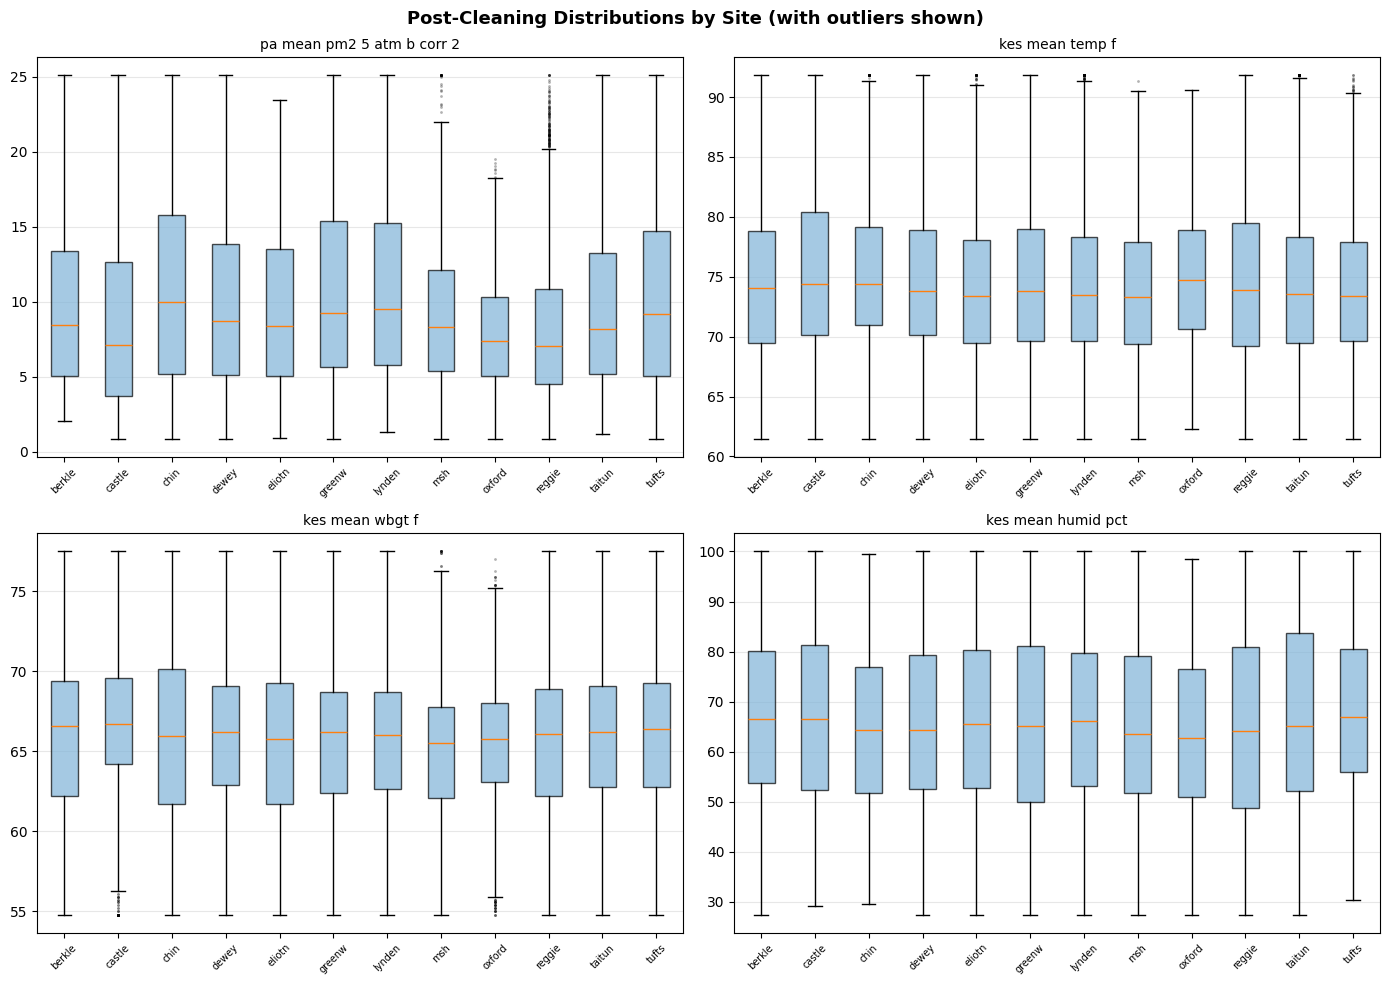

In [ ]:
# Outlier audit visualization — boxplots per site after cleaning
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, var in zip(axes.flatten(), iqr_vars):
    data_to_plot = [df.loc[df["siteID"] == s, var].dropna().values for s in sites]
    bp = ax.boxplot(
        data_to_plot, patch_artist=True, showfliers=True,
        flierprops=dict(marker=".", markersize=2, alpha=0.3),
    )
    for patch in bp["boxes"]:
        patch.set_facecolor("#7fb3d8")
        patch.set_alpha(0.7)
    ax.set_xticklabels([s[:6] for s in sites], rotation=45, fontsize=7)
    ax.set_title(var.replace("_", " "), fontsize=10)
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Post-Cleaning Distributions by Site (with outliers shown)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 1.7 — Data Normalization & Type Standardization

- Timezone: localized to `US/Eastern`
- Numeric coercion: all sensor columns cast to `float64`
- Column renaming: `siteID` → `site_id`, `date` → `datetime`
- Derived features: `hour`, `day_of_week`, `date_only`, `is_daytime`

In [ ]:
# Timezone
if df["date"].dt.tz is None:
    df["date"] = df["date"].dt.tz_localize("US/Eastern")
    print("✓ Datetime localized to US/Eastern")
else:
    df["date"] = df["date"].dt.tz_convert("US/Eastern")
    print("✓ Datetime converted to US/Eastern")

# Numeric coercion (safety pass)
numeric_targets = [c for c in df.columns if c not in ("siteID", "date") and not c.startswith("imputed_")]
for col in numeric_targets:
    if df[col].dtype == object:
        before_non_null = df[col].notna().sum()
        df[col] = pd.to_numeric(df[col], errors="coerce")
        after_non_null = df[col].notna().sum()
        coerced = before_non_null - after_non_null
        if coerced > 0:
            print(f"  {col}: coerced {coerced} non-numeric values to NaN")

# Column renaming
rename_map = {"siteID": "site_id", "date": "datetime"}
df.rename(columns=rename_map, inplace=True)
print(f"✓ Renamed columns: {rename_map}")

# Site ID normalization
df["site_id"] = df["site_id"].str.strip().str.lower()
print(f"✓ site_id normalized: {sorted(df['site_id'].unique())}")

# Derived time columns
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek
df["date_only"] = df["datetime"].dt.date
df["is_daytime"] = df["hour"].between(6, 17)  # 6am–6pm
print("✓ Added derived columns: hour, day_of_week, date_only, is_daytime")

✓ Datetime localized to US/Eastern
✓ Renamed columns: {'siteID': 'site_id', 'date': 'datetime'}
✓ site_id normalized: ['berkley', 'castle', 'chin', 'dewey', 'eliotnorton', 'greenway', 'lyndenboro', 'msh', 'oxford', 'reggie', 'taitung', 'tufts']
✓ Added derived columns: hour, day_of_week, date_only, is_daytime


## 1.8 — Merge & Final Cleaned Dataset

Three merges:
1. **EPA hourly pollutants** — joined on floored-hour datetime
2. **Land-use buffers** — pivoted to wide format (5 vars × 2 distances) and joined on `site_id`
3. **Export** — Parquet + CSV

In [ ]:
# --- Merge EPA hourly data ---
if epa_merged is not None:
    df["datetime_hour"] = df["datetime"].dt.floor("h")
    epa_idx = epa_merged.set_index("datetime") if "datetime" in epa_merged.columns else epa_merged
    if epa_idx.index.tz is not None:
        epa_idx.index = epa_idx.index.tz_localize(None)
    df["datetime_hour_naive"] = df["datetime_hour"].dt.tz_localize(None)

    df = df.merge(epa_idx, left_on="datetime_hour_naive", right_index=True, how="left")
    df.drop(columns=["datetime_hour", "datetime_hour_naive"], inplace=True)

    epa_cols = [c for c in df.columns if c.startswith("epa_")]
    for col in epa_cols:
        filled = df[col].notna().sum()
        print(f"  EPA {col}: {filled}/{len(df)} rows matched ({filled/len(df)*100:.1f}%)")
else:
    print("  ⚠ No EPA data to merge")

  EPA epa_ozone: 46848/48123 rows matched (97.4%)
  EPA epa_so2: 44957/48123 rows matched (93.4%)
  EPA epa_co: 46995/48123 rows matched (97.7%)
  EPA epa_no2: 41518/48123 rows matched (86.3%)
  EPA epa_pm25_fem: 47395/48123 rows matched (98.5%)


In [ ]:
# --- Merge land-use data ---
lu["site_id"] = lu["Site"].map(LANDUSE_NAME_TO_ID)

lu_25 = lu[lu["Distance"] == 25].set_index("site_id")[
    ["Roads_Area_Percent", "Greenspace_Area_Percent", "Trees_Area_Percent",
     "Impervious_Area_Percent", "Industrial_Area_Percent"]
].add_suffix("_25m")

lu_50 = lu[lu["Distance"] == 50].set_index("site_id")[
    ["Roads_Area_Percent", "Greenspace_Area_Percent", "Trees_Area_Percent",
     "Impervious_Area_Percent", "Industrial_Area_Percent"]
].add_suffix("_50m")

lu_wide = lu_25.join(lu_50)
print(f"Land-use wide table ({lu_wide.shape[0]} sites × {lu_wide.shape[1]} cols):")
display(lu_wide.round(3))

df = df.merge(lu_wide, left_on="site_id", right_index=True, how="left")

lu_cols = [c for c in df.columns if c.endswith(("_25m", "_50m"))]
lu_filled = df[lu_cols[0]].notna().sum() if lu_cols else 0
print(f"Land-use merge: {lu_filled}/{len(df)} rows with data ({lu_filled/len(df)*100:.1f}%)")

Land-use wide table (12 sites × 10 cols):


,Roads_Area_Percent_25m,Greenspace_Area_Percent_25m,Trees_Area_Percent_25m,Impervious_Area_Percent_25m,Industrial_Area_Percent_25m,Roads_Area_Percent_50m,Greenspace_Area_Percent_50m,Trees_Area_Percent_50m,Impervious_Area_Percent_50m,Industrial_Area_Percent_50m
site_id,,,,,,,,,,
berkley,0.467,0.260,0.274,0.658,0.000,0.278,0.168,0.338,0.626,0.000
castle,0.000,0.000,0.707,0.297,0.000,0.000,0.000,0.671,0.427,0.000
chin,0.241,0.132,0.199,0.867,0.076,0.166,0.051,0.166,0.949,0.124
dewey,0.101,0.144,0.109,0.919,0.000,0.318,0.126,0.076,0.946,0.006
eliotnorton,0.122,0.274,0.496,0.539,0.000,0.277,0.213,0.310,0.673,0.000
lyndenboro,0.317,0.202,0.400,0.702,0.000,0.195,0.216,0.276,0.677,0.000
msh,0.223,0.000,0.171,0.955,0.000,0.163,0.000,0.254,0.925,0.000
greenway,0.182,0.121,0.074,0.869,0.000,0.294,0.049,0.069,0.954,0.000
oxford,0.000,0.000,0.015,1.000,0.000,0.000,0.000,0.004,1.000,0.068


Land-use merge: 48123/48123 rows with data (100.0%)


In [ ]:
# --- Export ---
df_flat = df.copy()
df_flat["datetime"] = df_flat["datetime"].dt.tz_localize(None)
df_flat["date_only"] = df_flat["date_only"].astype(str)

output_dir = Path('../../data/clean')
output_dir.mkdir(parents=True, exist_ok=True)

df_flat.to_parquet(output_dir / "data_HEROS_clean.parquet", index=False, engine="pyarrow")
print(f"✓ Exported data_HEROS_clean.parquet")

df_flat.to_csv(output_dir / "data_HEROS_clean.csv", index=False)
print(f"✓ Exported data_HEROS_clean.csv")

# --- Final summary ---
print(f"\nFinal dataset shape: {df_flat.shape[0]:,} rows × {df_flat.shape[1]} columns")
print(f"Sites: {sorted(df_flat['site_id'].unique().tolist())}")
print(f"Overall missingness: {df_flat.isna().sum().sum() / df_flat.size * 100:.3f}%")

print(f"\n=== Column Groups ===")
groups = {
    'Identifiers': ['site_id', 'datetime'],
    'Kestrel sensors': [c for c in df_flat.columns if c.startswith('kes_')],
    'Purple Air': ['pa_mean_pm2_5_atm_b_corr_2'],
    'Weather Station': [c for c in df_flat.columns if c.startswith('mean_') or c == 'wind_direction_degrees_kr'],
    'MassDEP FEM': [c for c in df_flat.columns if c.startswith('dep_')],
    'Imputation flags': [c for c in df_flat.columns if c.startswith('imputed_')],
    'Time features': ['hour', 'day_of_week', 'date_only', 'is_daytime'],
    'Land-use': [c for c in df_flat.columns if 'Percent' in c],
    'EPA AQS': [c for c in df_flat.columns if c.startswith('epa_')],
}
for name, cols in groups.items():
    print(f"  {name}: {len(cols)} columns")

✓ Exported data_HEROS_clean.parquet
✓ Exported data_HEROS_clean.csv

Final dataset shape: 48,123 rows × 46 columns
Sites: ['berkley', 'castle', 'chin', 'dewey', 'eliotnorton', 'greenway', 'lyndenboro', 'msh', 'oxford', 'reggie', 'taitung', 'tufts']
Overall missingness: 1.099%

=== Column Groups ===
  Identifiers: 2 columns
  Kestrel sensors: 6 columns
  Purple Air: 1 columns
  Weather Station: 7 columns
  MassDEP FEM: 4 columns
  Imputation flags: 7 columns
  Time features: 4 columns
  Land-use: 10 columns
  EPA AQS: 5 columns


In [ ]:
# Save Phase 1 report JSON
report["final_dataset"] = {
    "rows": int(df_flat.shape[0]),
    "cols": int(df_flat.shape[1]),
    "columns": df_flat.columns.tolist(),
    "overall_null_pct": round(df_flat.isna().sum().sum() / df_flat.size * 100, 3),
    "sites": sorted(df_flat["site_id"].unique().tolist()),
}
report["site_mapping"] = SITE_ID_TO_NAME

with open("phase1_report.json", "w") as f:
    json.dump(report, f, indent=2, default=str)
print("✓ Saved phase1_report.json")
print("\n✅ Phase 1 complete.")

✓ Saved phase1_report.json

✅ Phase 1 complete.


## Phase 1 Assessment

| Step | Description | Status |
|------|-------------|--------|
| 1.1 | Dataset catalog | ✅ 3 local + 5 EPA datasets cataloged |
| 1.2 | Data inspection | ✅ Structure, types, distributions verified |
| 1.3 | EPA fetch & merge | ✅ 5 pollutants (Ozone, SO₂, CO, NO₂, PM2.5) integrated |
| 1.4 | Missing value audit | ✅ Per-variable & per-site classification (MCAR/MAR) |
| 1.5 | Imputation | ✅ Tiered strategy with boolean tracking flags |
| 1.6 | Outlier detection | ✅ Physical bounds + IQR flagging + winsorization |
| 1.7 | Normalization | ✅ Types, units, derived features standardized |
| 1.8 | Final merge & export | ✅ 48,123 × 46+, <2% missingness |

### Notes for Phase 2
- EPA NO₂ has highest missingness (13.7%) — consider in pollutant correlations
- Kestrel gaps are site-specific (Castle Sq, Eliot Norton) — not random
- 151 negative PM2.5 values removed (not imputed) — sensitivity analysis recommended

**Phase 1 is complete. Dataset is clean and ready for Phase 2: Exploratory Data Analysis.**